# Ulgurji mijozlarni xarajat turlariga qarab segmentlash

Bu loyihada ulgurji savdo mijozlarini ular sarflaydigan mahsulot turlariga qarab K-means yordamida guruhlarga (segmentlarga) ajratamiz. Natijada marketologlar har bir segmentga mos taklif tayyorlay oladi.

**Dataset:** [UCI, Wholesale customers](https://archive.ics.uci.edu/ml/datasets/wholesale+customers) (440 mijoz).

| Ustun | Ma'nosi |
|---|---|
| `Channel` | mijoz turi: 1 - HoReCa (mehmonxona, restoran, kafe), 2 - chakana savdo |
| `Region` | hudud: 1 - Lisbon, 2 - Oporto, 3 - boshqa |
| `Fresh` | yangi mahsulotlarga sarflangan summa |
| `Milk` | sut mahsulotlari |
| `Grocery` | oziq-ovqat mahsulotlari |
| `Frozen` | muzlatilgan mahsulotlar |
| `Detergents_Paper` | tozalash vositalari va qog'oz mahsulotlari |
| `Delicassen` | delikates mahsulotlar |

**Ish tartibi:** ma'lumotni tayyorlaymiz va normallashtiramiz, K-means bilan klasterlaymiz, natijani vizualizatsiya qilamiz va har bir segmentni tahlil qilamiz.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/alishermutalov/praktikum-datasets/refs/heads/praktikum/Wholesale_customers_data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## 1. Ma'lumotni tayyorlaymiz
### 1.1. Ma'lumotni o'rganamiz

In [2]:
print("Shakl:", df.shape)
print("\nBo'sh qiymatlar:\n", df.isnull().sum())
print("\nDublikatlar soni:", df.duplicated().sum())
df.describe().round(1)

Shakl: (440, 8)

Bo'sh qiymatlar:
 Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Dublikatlar soni: 0


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0
mean,1.3,2.5,12000.3,5796.3,7951.3,3071.9,2881.5,1524.9
std,0.5,0.8,12647.3,7380.4,9503.2,4854.7,4767.9,2820.1
min,1.0,1.0,3.0,55.0,3.0,25.0,3.0,3.0
25%,1.0,2.0,3127.8,1533.0,2153.0,742.2,256.8,408.2
50%,1.0,3.0,8504.0,3627.0,4755.5,1526.0,816.5,965.5
75%,2.0,3.0,16933.8,7190.2,10655.8,3554.2,3922.0,1820.2
max,2.0,3.0,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0


**Tushuntirish**
- `df.shape`: qator va ustunlar soni.
- `df.isnull().sum()`: har bir ustundagi bo'sh qiymatlar soni.
- `df.duplicated().sum()`: takroriy qatorlar soni.
- `df.describe()`: statistikalar. Xarajat ustunlarida o'rtacha qiymat mediandan ancha katta bo'lsa, taqsimot o'ng tomonga cho'zilgan (skewed) va katta outlierlar bor degani.

### 1.2. Xarajat ustunlari taqsimoti

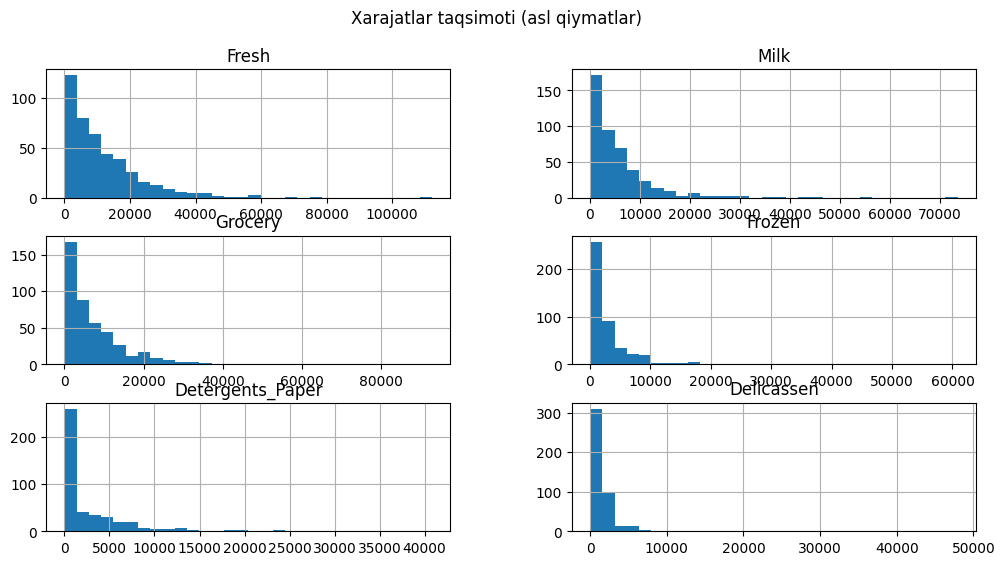

Skewness (assimetriya):
Fresh                2.56
Milk                 4.05
Grocery              3.59
Frozen               5.91
Detergents_Paper     3.63
Delicassen          11.15
dtype: float64


In [3]:
spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

df[spend_cols].hist(bins=30, figsize=(12, 6))
plt.suptitle("Xarajatlar taqsimoti (asl qiymatlar)")
plt.show()

print("Skewness (assimetriya):")
print(df[spend_cols].skew().round(2))

**Tushuntirish**
- `spend_cols`: faqat xarajat ustunlari ro'yxati.
- `hist(bins=30)`: har bir ustun uchun gistogramma.
- `skew()`: assimetriya ko'rsatkichi. 0 ga yaqin bo'lsa simmetrik, katta musbat son kuchli o'ng dumni bildiradi.
- K-means masofaga asoslangan, shuning uchun kuchli assimetriya klasterlarni buzishi mumkin. Buni keyingi qadamda logarifm bilan tuzatamiz.

### 1.3. `Channel` va `Region` ni ajratib olamiz

In [4]:
# Klasterlashda ishlatmaymiz, lekin keyin tahlil uchun saqlab qo'yamiz
meta = df[['Channel', 'Region']].copy()

X = df[spend_cols].copy()
X.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


**Tushuntirish**
- Maqsad aynan xarajat odatlari bo'yicha segmentlash, shuning uchun `Channel` va `Region` ni klasterlashga **kiritmaymiz**.
- `meta`: ikki ustunni alohida saqlaymiz, klasterlar tayyor bo'lgach ular qaysi kanal va hududga to'g'ri kelishini tekshiramiz.
- `X`: klasterlash uchun faqat 6 ta xarajat ustuni.

### 1.4. Normallashtiramiz (logarifm + standartlashtirish)

In [5]:
from sklearn.preprocessing import StandardScaler

X_log = np.log1p(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print("Log'dan keyingi skewness:")
print(X_log.skew().round(2))

Log'dan keyingi skewness:
Fresh              -1.58
Milk               -0.22
Grocery            -0.67
Frozen             -0.35
Detergents_Paper   -0.24
Delicassen         -1.09
dtype: float64


**Tushuntirish**
- `np.log1p(X)`: `log(1 + x)` ni hisoblaydi. Kuchli o'ng dumni qisqartiradi, `1 +` esa nol qiymatlar uchun xavfsiz.
- `StandardScaler()`: har bir ustunni o'rtacha 0 va standart og'ish 1 ga keltiradi. Shunda summasi katta ustun (masalan, `Fresh`) klasterlashda boshqalarni bosib ketmaydi.
- `fit_transform(X_log)`: parametrlarni hisoblab, ma'lumotni o'zgartiradi. Natija `X_scaled` (numpy massivi).
- `X_log.skew()`: assimetriya log'dan keyin kamayganini ko'rsatadi.

## 2. K-means bilan klasterlaymiz
### 2.1. Klasterlar sonini tanlaymiz (Elbow va Silhouette)

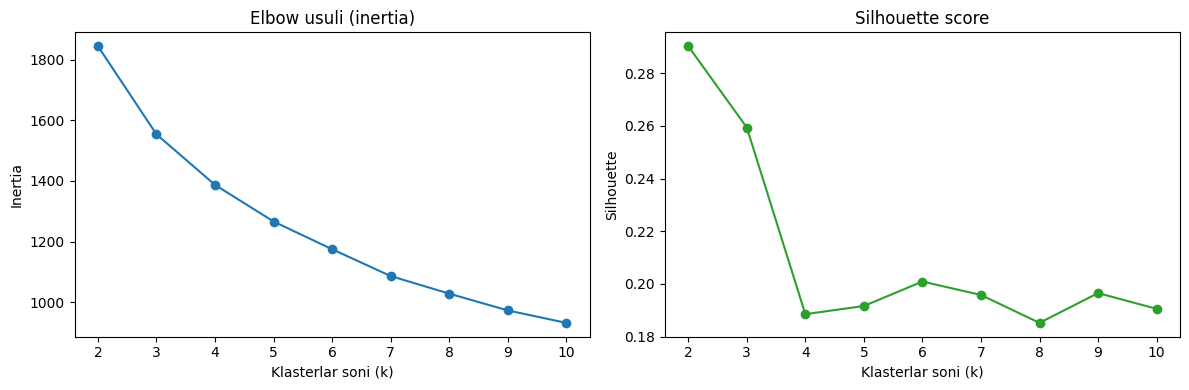

,k,inertia,silhouette
0,2,1844.1,0.290
1,3,1553.4,0.259
2,4,1386.9,0.188
3,5,1266.1,0.192
4,6,1174.8,0.201
5,7,1086.4,0.196
6,8,1028.5,0.185
7,9,973.1,0.197
8,10,932.0,0.191


In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 11)
inertias, sil_scores = [], []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_title("Elbow usuli (inertia)")
axes[0].set_xlabel("Klasterlar soni (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_range), sil_scores, marker='o', color='tab:green')
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Klasterlar soni (k)")
axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

pd.DataFrame({'k': list(K_range), 'inertia': np.round(inertias, 1),
              'silhouette': np.round(sil_scores, 3)})

**Tushuntirish**
- `K_range = range(2, 11)`: k = 2 dan 10 gacha sinab ko'ramiz.
- `KMeans(n_clusters=k, n_init=10, random_state=42)`: `n_init=10` markazlarni 10 marta tasodifiy boshlab eng yaxshisini tanlaydi; `random_state=42` natijani takrorlanuvchan qiladi.
- `fit_predict`: modelni o'qitadi va har bir mijozga klaster raqamini beradi.
- `inertia_`: nuqtalarning o'z markazigacha masofalari kvadratlari yig'indisi. Kichikroq yaxshiroq, lekin k oshgani sari doim kamayadi.
- **Elbow usuli**: grafikda egilish ("tirsak") paydo bo'lgan joy yaxshi k ni ko'rsatadi.
- `silhouette_score`: klasterlar qanchalik ajralganini o'lchaydi (-1 dan 1 gacha), yuqori bo'lgani yaxshi.

### 2.2. Yakuniy modelni o'qitamiz

In [7]:
best_k = K_range[int(np.argmax(sil_scores))]
print("Silhouette bo'yicha eng yaxshi k:", best_k)

# Elbow grafigiga qarab boshqa k tanlamoqchi bo'lsak, shu yerda o'zgartiramiz:
k_final = best_k

kmeans = KMeans(n_clusters=k_final, n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\nSilhouette:", round(silhouette_score(X_scaled, df['Cluster']), 3))
df['Cluster'].value_counts().sort_index()

Silhouette bo'yicha eng yaxshi k: 2

Silhouette: 0.29


,count
Cluster,
0,252
1,188


**Tushuntirish**
- `np.argmax(sil_scores)`: eng katta silhouette qiymatining o'rnini topadi, `best_k` shu k bo'ladi.
- `k_final`: yakuniy k. Elbow grafigiga qarab boshqa qiymat (masalan, 3 yoki 4) tanlasak bo'ladi, faqat shu qatorni o'zgartiramiz.
- `df['Cluster']`: har bir mijozga klaster raqami yoziladi.
- `value_counts()`: har bir klasterda nechta mijoz borligini ko'rsatadi.

## 3. Natijalarni vizualizatsiya qilamiz
### 3.1. PCA yordamida 2D scatter plot

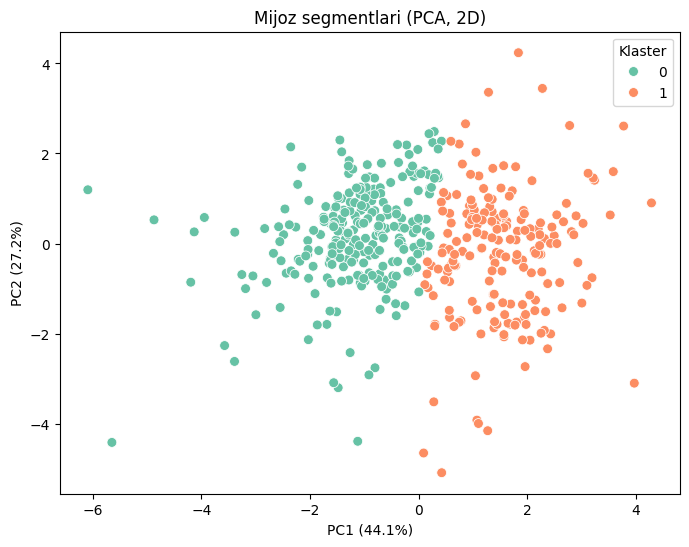

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pcs[:, 0], y=pcs[:, 1], hue=df['Cluster'], palette='Set2', s=50)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Mijoz segmentlari (PCA, 2D)")
plt.legend(title="Klaster")
plt.show()

**Tushuntirish**
- Ma'lumotda 6 ta o'lchov bor, uni to'g'ridan-to'g'ri chizib bo'lmaydi. `PCA(n_components=2)` uni eng ko'p ma'lumotni saqlagan 2 ta o'qqa (PC1, PC2) qisqartiradi.
- `explained_variance_ratio_`: har bir o'q ma'lumot o'zgaruvchanligining necha foizini tushuntirishini beradi (o'q nomida chiqadi).
- `sns.scatterplot(hue=df['Cluster'])`: nuqtalar klaster bo'yicha rangga bo'yaladi.

### 3.2. Pairplot

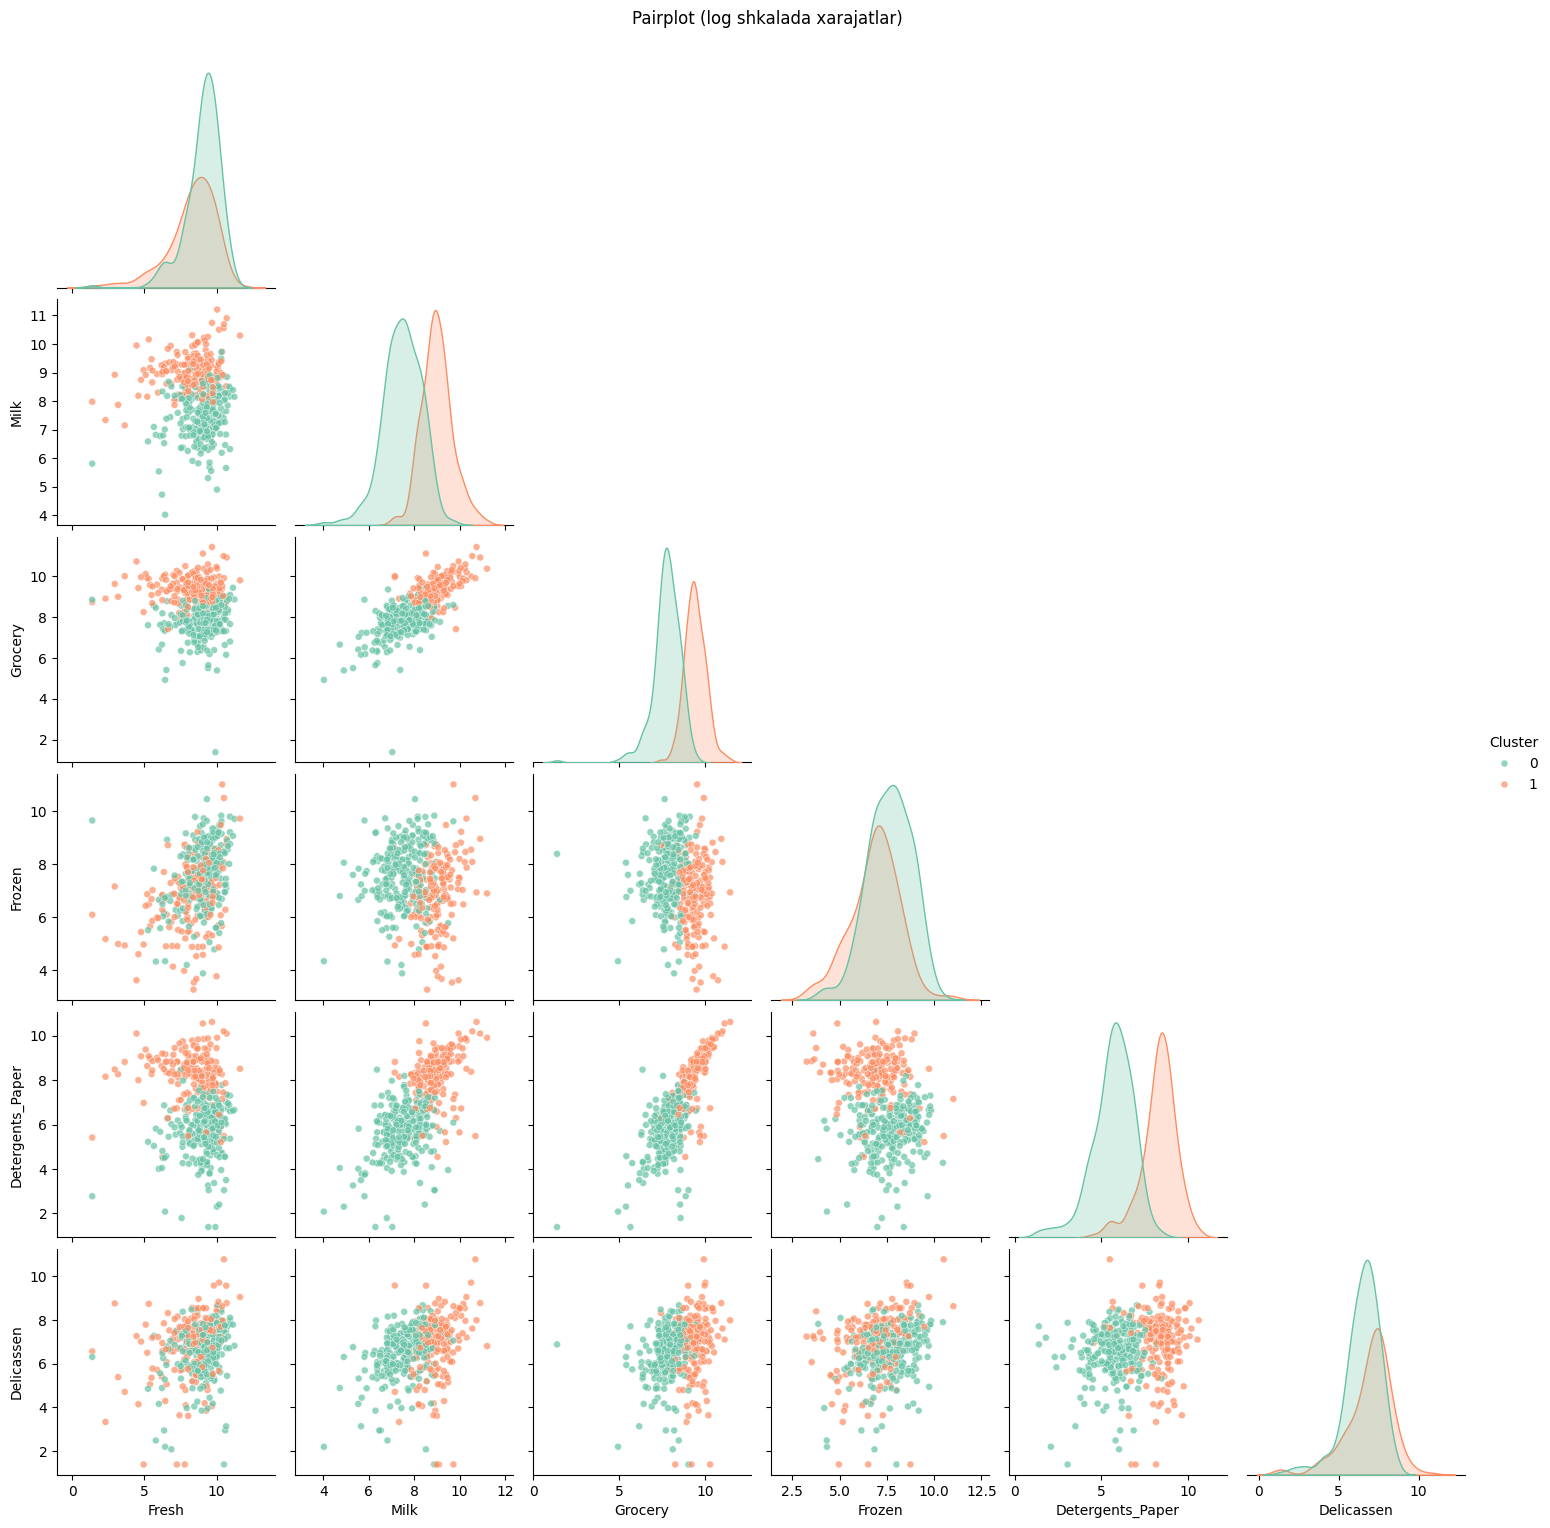

In [9]:
plot_df = pd.DataFrame(X_log.values, columns=spend_cols)
plot_df['Cluster'] = df['Cluster'].values

sns.pairplot(plot_df, hue='Cluster', palette='Set2', corner=True,
             plot_kws={'s': 25, 'alpha': 0.7})
plt.suptitle("Pairplot (log shkalada xarajatlar)", y=1.02)
plt.show()

**Tushuntirish**
- `plot_df`: log o'zgartirilgan xarajatlar va klaster raqami. Log shkala nuqtalarni ko'rinarli qiladi.
- `sns.pairplot(hue='Cluster')`: har bir juft ustun uchun scatter plot va diagonalda taqsimot chizadi.
- `corner=True`: takroriy yuqori uchburchakni olib tashlaydi, grafik yengillashadi.

### 3.3. Har bir segmentning o'rtacha xarajatlari

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,13973.0,2402.0,2919.0,3706.0,492.0,1038.0
1,9356.0,10346.0,14697.0,2222.0,6085.0,2177.0


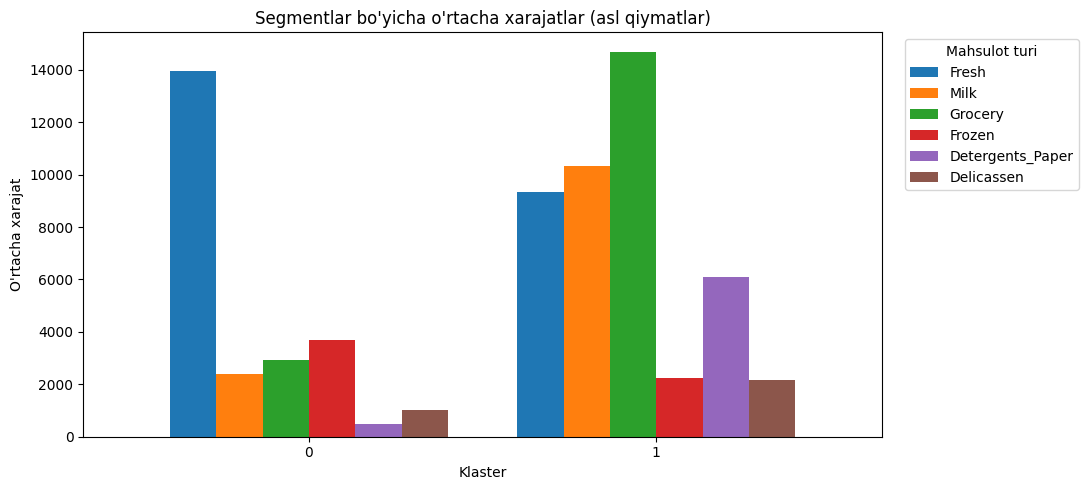

In [10]:
cluster_means = df.groupby('Cluster')[spend_cols].mean().round(0)
display(cluster_means)

cluster_means.plot(kind='bar', figsize=(11, 5), width=0.8)
plt.title("Segmentlar bo'yicha o'rtacha xarajatlar (asl qiymatlar)")
plt.xlabel("Klaster")
plt.ylabel("O'rtacha xarajat")
plt.xticks(rotation=0)
plt.legend(title="Mahsulot turi", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Tushuntirish**
- `groupby('Cluster')[spend_cols].mean()`: har bir klaster uchun har bir mahsulot turi bo'yicha o'rtacha xarajat. Bu yerda log emas, **asl summalar** olinadi, shunda natijani biznes tilida o'qish oson.
- `plot(kind='bar')`: klasterlarni xarajat turlari bo'yicha ustunli diagrammada solishtiradi.
- `display(...)`: jadvalni chiroyli ko'rinishda chiqaradi.

### 3.4. Heatmap: klasterlarning nisbiy xarajat profili

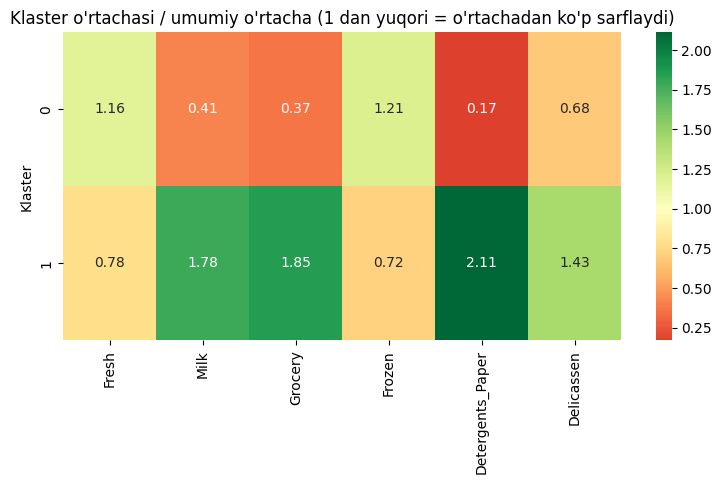

In [11]:
profile = cluster_means.div(df[spend_cols].mean(), axis=1)

plt.figure(figsize=(9, 4))
sns.heatmap(profile, annot=True, fmt=".2f", cmap="RdYlGn", center=1)
plt.title("Klaster o'rtachasi / umumiy o'rtacha (1 dan yuqori = o'rtachadan ko'p sarflaydi)")
plt.ylabel("Klaster")
plt.show()

**Tushuntirish**
- `cluster_means.div(df[spend_cols].mean(), axis=1)`: har bir klaster o'rtachasini butun mijozlar o'rtachasiga bo'lamiz.
- Qiymat **1 dan katta** bo'lsa, klaster shu mahsulotga o'rtachadan ko'p, **1 dan kichik** bo'lsa kam sarflaydi.
- `sns.heatmap(annot=True)`: qiymatlar katak ichida yoziladi.

### 3.5. Segmentlarning qisqa tavsifi

In [12]:
sizes = df['Cluster'].value_counts().sort_index()

for c in profile.index:
    row = profile.loc[c].sort_values(ascending=False)
    high = ", ".join(f"{n} (x{v:.1f})" for n, v in row.head(2).items())
    low = ", ".join(f"{n} (x{v:.1f})" for n, v in row.tail(2)[::-1].items())
    print(f"Klaster {c} ({sizes[c]} mijoz)")
    print(f"  Ko'p sarflaydi : {high}")
    print(f"  Kam sarflaydi  : {low}\n")

Klaster 0 (252 mijoz)
  Ko'p sarflaydi : Frozen (x1.2), Fresh (x1.2)
  Kam sarflaydi  : Detergents_Paper (x0.2), Grocery (x0.4)

Klaster 1 (188 mijoz)
  Ko'p sarflaydi : Detergents_Paper (x2.1), Grocery (x1.8)
  Kam sarflaydi  : Frozen (x0.7), Fresh (x0.8)



**Tushuntirish**
- `profile`: 3.4 dagi nisbiy ko'rsatkich. Har bir klaster uchun uni saralab, eng yuqori 2 ta va eng past 2 ta mahsulot turini topamiz.
- `x2.1` kabi yozuv: klaster shu mahsulotga umumiy o'rtachadan necha marta ko'p yoki kam sarflashini bildiradi.
- Shu qisqa tavsif asosida har bir segmentga nom beramiz va tavsiya yozamiz.

### 3.6. Klasterlar va `Channel` / `Region` bog'liqligi

In [13]:
df_meta = pd.concat([meta, df['Cluster']], axis=1)

print("Channel bo'yicha (qator bo'yicha %):")
display((pd.crosstab(df_meta['Cluster'], df_meta['Channel'], normalize='index') * 100).round(1))

print("Region bo'yicha (qator bo'yicha %):")
display((pd.crosstab(df_meta['Cluster'], df_meta['Region'], normalize='index') * 100).round(1))

Channel bo'yicha (qator bo'yicha %):


Channel,1,2
Cluster,,
0,96.8,3.2
1,28.7,71.3


Region bo'yicha (qator bo'yicha %):


Region,1,2,3
Cluster,,,
0,19.0,11.1,69.8
1,15.4,10.1,74.5


**Tushuntirish**
- Klasterlashda `Channel` va `Region` ishlatilmagan edi. Endi ular klasterlarni tushuntirishga yordam beradi.
- `pd.crosstab(..., normalize='index')`: har bir klaster ichida kanal (1 - HoReCa, 2 - chakana) va hudud (1 - Lisbon, 2 - Oporto, 3 - boshqa) ulushini foizda beradi.
- Biror klaster deyarli to'liq bir kanalga to'g'ri kelsa, bu segment shu kanalning odatini aks ettiradi.

## 4. Xulosa va marketing tavsiyalari

Segmentlarni 3.3 - 3.6 bo'limlaridagi natijalarga qarab nomlaymiz. Quyida segment turiga qarab tavsiyalar keltirilgan:

| Agar segmentda ... yuqori bo'lsa | Ehtimoliy mijoz turi | Tavsiya |
|---|---|---|
| `Fresh`, `Frozen`, `Delicassen` | HoReCa (restoran, kafe, mehmonxona) | Yangi va muzlatilgan mahsulotlarni tez yetkazib berish, doimiy buyurtma jadvali, hajmiy chegirmalar |
| `Grocery`, `Milk`, `Detergents_Paper` | Chakana savdo (do'kon, supermarket) | Sut, oziq-ovqat va tozalash vositalarini to'plam (bundle) qilib sotish, kross-sotuv |
| Deyarli barcha toifalar | Yirik mijozlar | Shaxsiy menejer, maxsus narx shartnomalari, sodiqlik dasturi |
| Hamma toifada past | Kichik yoki faol bo'lmagan mijozlar | Ikkinchi toifadan taklif qilib, o'rtacha chekni oshirish |

**Umumiy tavsiyalar**
1. Har bir segment uchun alohida reklama xabari va aksiya tayyorlaymiz.
2. Eng qimmatli segmentni yo'qotmaslik uchun unga alohida xizmat ko'rsatamiz.
3. Klasterlashni vaqti-vaqti bilan qayta o'tkazib, mijozlar segmentlar orasida qanday ko'chayotganini kuzatamiz.